# PHASE 7 — Loss Function & Training Loop
## Multimodal Maritime Object Detection Using SAR and Optical Satellite Imagery
---
**Team 22UG0005 | Panel No. 5 | Guide: Mr. Nagesh Koundinya Subbanna**

---
## WHAT IS PHASE 7?

THIS is where the model actually LEARNS to detect ships.
All previous phases (0-6) were preparation and architecture.
Phase 7 is the engine that trains the entire network.

---
## WHAT HAPPENS IN TRAINING:

```
Repeat for 20 EPOCHS:

  For each BATCH (2250 batches per epoch, 4 images each):

    STEP 1 - FORWARD PASS:
    SAR + Optical -> Phase4 backbone -> Phase5 fusion -> Phase6 head
    -> raw predictions (pred_P3, pred_P4, pred_P5)

    STEP 2 - COMPUTE LOSS:
    Compare predictions vs ground truth YOLO labels
    L_bbox = CIoU loss    (box accuracy)
    L_obj  = BCE loss     (objectness)
    L_cls  = BCE loss     (ship class)
    L_total = L_bbox + L_obj + L_cls

    STEP 3 - BACKWARD PASS:
    L_total.backward()  -> compute gradients
    Every 2 steps: optimiser.step() -> update ALL weights
    (gradient accumulation: simulates batch=8 on CPU memory for batch=4)

  After each epoch: validate on 1,000 val images
  Every 5 epochs : save checkpoint
  Always          : save best model by val mAP
```

---
## THREE LOSS COMPONENTS EXPLAINED:

```
L_bbox (CIoU Loss):
  Measures how well the predicted box matches the ground truth box.
  CIoU = Complete IoU penalises THREE things simultaneously:
    1. Overlap area  (are they the same size and position?)
    2. Centre distance (are centres aligned?)
    3. Aspect ratio difference (is the shape correct?)
  Better than plain IoU, MSE, or GIoU for detection tasks.

L_obj (Objectness BCE):
  For EVERY grid cell in EVERY head:
    If a ship is there  -> objectness should be 1.0
    If no ship is there -> objectness should be 0.0
  Most cells have no ship -> model learns to predict 0 everywhere
  except where ships actually are.

L_cls (Classification BCE):
  For cells WHERE a ship is present:
    Class probability should be 1.0 (it IS a ship)
  Only 1 class in this project, so this is simple binary cross-entropy.
```

---
## INPUT/OUTPUT OF PHASE 7:

```
INPUT:
  train_loader  (Phase 3) -> batches of (SAR, optical, labels)
  val_loader    (Phase 3) -> 1000 validation images
  Full model    (Phase 4 + 5 + 6) -> all weights to be trained

OUTPUT:
  best_model.pth          -> weights with highest val mAP
  checkpoint_epoch_5.pth  -> saved every 5 epochs
  checkpoint_epoch_10.pth
  ...
  training_log.csv        -> loss and mAP per epoch
  training_curves.png     -> loss and mAP curves for report
```

## Cell 1 - Install Libraries

In [1]:
import subprocess, sys
required = ['torch', 'torchvision', 'numpy', 'pandas',
            'matplotlib', 'tqdm', 'opencv-python']
for pkg in required:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All libraries installed.')

All libraries installed.


## Cell 2 - Imports

In [2]:
import os, sys, io, time, math, csv
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import ResNet50_Weights
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# Fix Windows Unicode
if hasattr(sys.stdout, "buffer"):
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8', errors='replace')
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cpu':
    torch.set_num_threads(8)

print('All imports successful.')
print(f'  PyTorch : {torch.__version__}')
print(f'  Device  : {device}')
print(f'  Run at  : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
if device.type == 'cpu':
    print()
    print('  Running on CPU. Training will take approximately:')
    print('  1-2 hours per epoch. 20 epochs = 20-40 hours total.')
    print('  TIP: Run overnight or over weekend.')

All imports successful.
  PyTorch : 2.11.0+cpu
  Device  : cpu
  Run at  : 2026-05-07 11:29:51

  Running on CPU. Training will take approximately:
  1-2 hours per epoch. 20 epochs = 20-40 hours total.
  TIP: Run overnight or over weekend.


## Cell 3 - Configuration

In [3]:
# =====================================================================
#   EDIT ONLY THIS CELL
# =====================================================================

ROOT         = r'C:\Users\VaishnaviM\Downloads\airbus-ship-detection'
DATASET_DIR  = os.path.join(ROOT, 'dataset')

# -- INPUT PATHS (from previous phases) -------------------------------
OPT_DIR      = os.path.join(DATASET_DIR, 'preprocessed_train_OPTICAL')
SAR_DIR      = os.path.join(DATASET_DIR, 'preprocessed_train_SAR')
LABEL_DIR    = os.path.join(DATASET_DIR, 'labels')

# -- OUTPUT PATHS -----------------------------------------------------
CHECKPOINT_DIR = os.path.join(DATASET_DIR, 'checkpoints')
LOG_DIR        = os.path.join(DATASET_DIR, 'training_logs')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR,        exist_ok=True)

BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
LOG_CSV_PATH    = os.path.join(LOG_DIR, 'training_log.csv')
SUMMARY_FILE    = os.path.join(DATASET_DIR, 'phase7_summary.txt')

# -- IMAGE SETTINGS ---------------------------------------------------
IMG_H        = 320
IMG_W        = 320

# -- DATASET SETTINGS (from Phase 3 methodology) ----------------------
NUM_SHIP_SAMPLES = 5000   # positive samples
NUM_BG_SAMPLES   = 5000   # negative samples
TOTAL_SAMPLES    = NUM_SHIP_SAMPLES + NUM_BG_SAMPLES   # 10,000
VAL_FRACTION     = 0.10   # 10% = 1,000 val images
SEED             = 42

# -- DATALOADER SETTINGS ----------------------------------------------
BATCH_SIZE   = 4      # hardware constraint: CPU + 16GB RAM
NUM_WORKERS  = 0      # Windows: must be 0 in Jupyter

# -- MODEL SETTINGS ---------------------------------------------------
FEAT_CH      = 256
NUM_ANCHORS  = 3
NUM_CLASSES  = 1
PRED_CELL    = NUM_ANCHORS * (4 + 1 + NUM_CLASSES)  # 18
SAR_CH       = (512, 1024, 2048)   # ResNet50 output channels
OPT_CH       = (256, 512,  1024)   # CSPDarknet output channels

ANCHORS = {
    'P3': [(6,4),   (10,6),  (14,8)],
    'P4': [(20,12), (28,18), (36,24)],
    'P5': [(50,30), (70,45), (90,60)],
}
STRIDES = {'P3': 8, 'P4': 16, 'P5': 32}

# -- TRAINING HYPERPARAMETERS (from methodology) ----------------------
NUM_EPOCHS          = 20       # CPU constraint (full scale = 50)
LEARNING_RATE       = 1e-3     # AdamW initial LR
WEIGHT_DECAY        = 0.01     # AdamW L2 regularisation
GRAD_ACCUM_STEPS    = 2        # accumulate 2 steps -> effective batch=8
CHECKPOINT_INTERVAL = 5        # save checkpoint every 5 epochs
UNFREEZE_EPOCH      = 10       # unfreeze backbone early layers at epoch 10

# -- LOSS WEIGHTS -----------------------------------------------------
LAMBDA_BBOX  = 5.0    # weight for bbox regression loss
LAMBDA_OBJ   = 1.0    # weight for objectness loss
LAMBDA_CLS   = 0.5    # weight for classification loss
LAMBDA_NOOBJ = 0.5    # weight for no-object cells (reduce dominance)

# -- IOU THRESHOLD FOR POSITIVE ASSIGNMENT ----------------------------
IOU_THRESHOLD = 0.5   # anchor is positive if IoU with gt >= 0.5
CONF_THRESHOLD= 0.5   # minimum confidence for val detections
NMS_THRESHOLD = 0.45  # NMS IoU threshold

print('Configuration loaded.')
print(f'  Device               : {device}')
print(f'  Epochs               : {NUM_EPOCHS}')
print(f'  Batch size           : {BATCH_SIZE}')
print(f'  Grad accumulation    : {GRAD_ACCUM_STEPS} steps (effective batch={BATCH_SIZE*GRAD_ACCUM_STEPS})')
print(f'  Learning rate        : {LEARNING_RATE}')
print(f'  Weight decay         : {WEIGHT_DECAY}')
print(f'  Dataset (train)      : {int(TOTAL_SAMPLES*(1-VAL_FRACTION)):,} images')
print(f'  Dataset (val)        : {int(TOTAL_SAMPLES*VAL_FRACTION):,} images')
print(f'  Checkpoint every     : {CHECKPOINT_INTERVAL} epochs')
print(f'  Unfreeze backbone at : epoch {UNFREEZE_EPOCH}')
print()
print('  Loss weights:')
print(f'    L_bbox  x {LAMBDA_BBOX}  (CIoU - box regression)')
print(f'    L_obj   x {LAMBDA_OBJ}  (BCE  - objectness)')
print(f'    L_cls   x {LAMBDA_CLS}  (BCE  - classification)')
print(f'    no_obj  x {LAMBDA_NOOBJ}  (reduce background dominance)')

Configuration loaded.
  Device               : cpu
  Epochs               : 20
  Batch size           : 4
  Grad accumulation    : 2 steps (effective batch=8)
  Learning rate        : 0.001
  Weight decay         : 0.01
  Dataset (train)      : 9,000 images
  Dataset (val)        : 1,000 images
  Checkpoint every     : 5 epochs
  Unfreeze backbone at : epoch 10

  Loss weights:
    L_bbox  x 5.0  (CIoU - box regression)
    L_obj   x 1.0  (BCE  - objectness)
    L_cls   x 0.5  (BCE  - classification)
    no_obj  x 0.5  (reduce background dominance)


## Cell 4 - Rebuild All Architecture Modules
### BUG FIX 1: SARBackbone.forward() — intermediate features recomputed 2-3x
**Original code** called `self.layer2(x)` three times, `self.layer3(...)` twice.
Each call re-runs all convolutions from scratch, so P4/P5 features were computed
on stale inputs and the forward pass was 3x slower than necessary.
**Fix:** store each stage output in a variable and reuse it.

In [4]:
# =====================================================================
#  ALL ARCHITECTURE MODULES IN ONE CELL
#  Phase 4A (ResNet50 + CSPDarknet) + Phase 5 (Fusion+FPN) + Phase 6 (Head)
#  Combined into a single MultimodalDetector class for training.
# =====================================================================

# -- Phase 4A: CSPDarknet blocks --------------------------------------
class ConvBnSilu(nn.Module):
    def __init__(self, in_ch, out_ch, k=1, s=1, p=0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, s, p, bias=False),
            nn.BatchNorm2d(out_ch), nn.SiLU(inplace=True))
    def forward(self, x): return self.conv(x)

class Bottleneck(nn.Module):
    def __init__(self, in_ch, out_ch, shortcut=True):
        super().__init__()
        h = out_ch // 2
        self.cv1 = ConvBnSilu(in_ch, h, 1)
        self.cv2 = ConvBnSilu(h, out_ch, 3, 1, 1)
        self.sc  = shortcut and in_ch == out_ch
    def forward(self, x):
        return x + self.cv2(self.cv1(x)) if self.sc else self.cv2(self.cv1(x))

class CSPLayer(nn.Module):
    def __init__(self, in_ch, out_ch, n=1):
        super().__init__()
        h = out_ch // 2
        self.cv1 = ConvBnSilu(in_ch, h)
        self.cv2 = ConvBnSilu(in_ch, h)
        self.bns = nn.Sequential(*[Bottleneck(h, h) for _ in range(n)])
        self.cv3 = ConvBnSilu(2*h, out_ch)
    def forward(self, x):
        return self.cv3(torch.cat([self.bns(self.cv1(x)), self.cv2(x)], 1))


# -- Phase 4A: SAR Backbone (ResNet50 1-channel) ----------------------
class SARBackbone(nn.Module):
    def __init__(self, pretrained=True, freeze_early=True):
        super().__init__()
        base = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1 if pretrained else None)
        old  = base.conv1
        new  = nn.Conv2d(1, old.out_channels, old.kernel_size, old.stride, old.padding, bias=False)
        with torch.no_grad():
            new.weight.copy_(old.weight.sum(dim=1, keepdim=True))
        base.conv1 = new
        self.stem   = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4
        if freeze_early:
            for p in list(self.stem.parameters()) + list(self.layer1.parameters()):
                p.requires_grad = False

    def forward(self, x):
        # BUG FIX 1: Store each stage in a variable.
        # Original code called self.layer2(x) three times and self.layer3(...) twice,
        # recomputing the same convolutions from scratch each time. P4 and P5
        # features were produced from stale inputs and the forward pass was 3x
        # slower than necessary.
        x  = self.stem(x)
        x  = self.layer1(x)
        s2 = self.layer2(x)   # Fs3: stride-8  features  [B, 512, H/8,  W/8]
        s3 = self.layer3(s2)  # Fs4: stride-16 features  [B, 1024, H/16, W/16]
        s4 = self.layer4(s3)  # Fs5: stride-32 features  [B, 2048, H/32, W/32]
        return s2, s3, s4

    def unfreeze(self):
        for p in self.parameters(): p.requires_grad = True


# -- Phase 4A: Optical Backbone (CSPDarknet) --------------------------
class OpticalBackbone(nn.Module):
    def __init__(self, freeze_early=True):
        super().__init__()
        self.stem   = nn.Sequential(ConvBnSilu(3,32,3,1,1), ConvBnSilu(32,64,3,2,1))
        self.stage1 = nn.Sequential(ConvBnSilu(64,128,3,2,1), CSPLayer(128,128,3))
        self.stage2 = nn.Sequential(ConvBnSilu(128,256,3,2,1), CSPLayer(256,256,9))
        self.stage3 = nn.Sequential(ConvBnSilu(256,512,3,2,1), CSPLayer(512,512,9))
        self.stage4 = nn.Sequential(ConvBnSilu(512,1024,3,2,1), CSPLayer(1024,1024,3))
        if freeze_early:
            for p in list(self.stem.parameters()) + list(self.stage1.parameters()):
                p.requires_grad = False
        for m in self.modules():
            if isinstance(m, nn.Conv2d): nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x):
        x = self.stem(x); x = self.stage1(x)
        P3 = self.stage2(x); P4 = self.stage3(P3); P5 = self.stage4(P4)
        return P3, P4, P5
    def unfreeze(self):
        for p in self.parameters(): p.requires_grad = True


# -- Phase 5: CrossModalAttention -------------------------------------
class CrossModalAttention(nn.Module):
    def __init__(self, sar_ch, opt_ch, out_ch=256, attn_dim=128, pool_size=4):
        super().__init__()
        self.attn_dim  = attn_dim
        self.pool_size = pool_size
        self.scale     = attn_dim ** -0.5
        self.proj_sar  = nn.Sequential(nn.Conv2d(sar_ch,attn_dim,1,bias=False), nn.BatchNorm2d(attn_dim), nn.ReLU(inplace=True))
        self.proj_opt  = nn.Sequential(nn.Conv2d(opt_ch,attn_dim,1,bias=False), nn.BatchNorm2d(attn_dim), nn.ReLU(inplace=True))
        self.q_proj    = nn.Linear(attn_dim, attn_dim, bias=False)
        self.k_proj    = nn.Linear(attn_dim, attn_dim, bias=False)
        self.v_proj    = nn.Linear(attn_dim, attn_dim, bias=False)
        self.o_proj    = nn.Linear(attn_dim, attn_dim, bias=False)
        self.norm_sar  = nn.LayerNorm(attn_dim)
        self.norm_opt  = nn.LayerNorm(attn_dim)
        self.merge     = nn.Sequential(nn.Conv2d(2*attn_dim,out_ch,1,bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, sar_feat, opt_feat):
        B, _, H, W = sar_feat.shape
        sp = self.proj_sar(sar_feat)
        op = self.proj_opt(opt_feat)
        op_pool = F.avg_pool2d(op, max(1,self.pool_size), stride=max(1,self.pool_size), padding=0)
        Q  = self.q_proj(self.norm_sar(sp.flatten(2).transpose(1,2)))
        KV = self.norm_opt(op_pool.flatten(2).transpose(1,2))
        K  = self.k_proj(KV); V = self.v_proj(KV)
        att = F.softmax(torch.bmm(Q, K.transpose(1,2)) * self.scale, dim=-1)
        out = self.o_proj(torch.bmm(att, V)).transpose(1,2).reshape(B, self.attn_dim, H, W)
        return self.merge(torch.cat([sp, out], dim=1))


# -- Phase 5: FPN Neck ------------------------------------------------
class FPNNeck(nn.Module):
    def __init__(self, feat_ch=256):
        super().__init__()
        self.lat5 = nn.Conv2d(feat_ch, feat_ch, 1, bias=False)
        self.lat4 = nn.Conv2d(feat_ch, feat_ch, 1, bias=False)
        self.lat3 = nn.Conv2d(feat_ch, feat_ch, 1, bias=False)
        def _out(c): return nn.Sequential(nn.Conv2d(c,c,3,padding=1,bias=False), nn.BatchNorm2d(c), nn.ReLU(inplace=True))
        self.out5 = _out(feat_ch); self.out4 = _out(feat_ch); self.out3 = _out(feat_ch)
        for m in self.modules():
            if isinstance(m, nn.Conv2d): nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, nn.BatchNorm2d): nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, P3, P4, P5):
        l5 = self.lat5(P5); l4 = self.lat4(P4); l3 = self.lat3(P3)
        o5 = self.out5(l5)
        o4 = self.out4(l4 + F.interpolate(o5, size=l4.shape[2:], mode='nearest'))
        o3 = self.out3(l3 + F.interpolate(o4, size=l3.shape[2:], mode='nearest'))
        return o3, o4, o5


# -- Phase 5: Full Fusion Module --------------------------------------
class FusionNeck(nn.Module):
    def __init__(self, sar_ch=(512,1024,2048), opt_ch=(256,512,1024), feat_ch=256, attn_dim=128):
        super().__init__()
        self.cma3 = CrossModalAttention(sar_ch[0], opt_ch[0], feat_ch, attn_dim, pool_size=4)
        self.cma4 = CrossModalAttention(sar_ch[1], opt_ch[1], feat_ch, attn_dim, pool_size=2)
        self.cma5 = CrossModalAttention(sar_ch[2], opt_ch[2], feat_ch, attn_dim, pool_size=1)
        self.fpn  = FPNNeck(feat_ch)
    def forward(self, Fs3,Fs4,Fs5,Fo3,Fo4,Fo5):
        return self.fpn(self.cma3(Fs3,Fo3), self.cma4(Fs4,Fo4), self.cma5(Fs5,Fo5))


# -- Phase 6: Detection Head ------------------------------------------
class DetHead(nn.Module):
    def __init__(self, in_ch, num_anchors, num_classes, anchors, stride):
        super().__init__()
        pred = num_anchors * (4 + 1 + num_classes)
        self.num_anchors = num_anchors
        self.num_classes = num_classes
        self.stride      = stride
        self.pred_ch     = pred
        self.register_buffer('anchors', torch.tensor(anchors, dtype=torch.float32))
        self.conv1 = nn.Sequential(nn.Conv2d(in_ch,in_ch,3,padding=1,bias=False), nn.BatchNorm2d(in_ch), nn.LeakyReLU(0.1,inplace=True))
        self.conv2 = nn.Sequential(nn.Conv2d(in_ch,in_ch,3,padding=1,bias=False), nn.BatchNorm2d(in_ch), nn.LeakyReLU(0.1,inplace=True))
        self.pred  = nn.Conv2d(in_ch, pred, 1, bias=True)
        bias_init  = -math.log((1-0.01)/0.01)
        with torch.no_grad():
            for i in range(num_anchors):
                self.pred.bias[i*(4+1+num_classes)+4] = bias_init
    def forward(self, x): return self.pred(self.conv2(self.conv1(x)))

class MultiScaleHead(nn.Module):
    def __init__(self, feat_ch=256, num_anchors=3, num_classes=1,
                 anchors=ANCHORS, strides=STRIDES):
        super().__init__()
        self.head3 = DetHead(feat_ch, num_anchors, num_classes, anchors['P3'], strides['P3'])
        self.head4 = DetHead(feat_ch, num_anchors, num_classes, anchors['P4'], strides['P4'])
        self.head5 = DetHead(feat_ch, num_anchors, num_classes, anchors['P5'], strides['P5'])
    def forward(self, P3, P4, P5):
        return self.head3(P3), self.head4(P4), self.head5(P5)


# -- Complete Model: Phase 4 + 5 + 6 ----------------------------------
class MultimodalDetector(nn.Module):
    """
    Complete multimodal ship detection model.
    Combines Phase 4A backbone + Phase 5 fusion + Phase 6 head.
    This is the model that gets TRAINED in Phase 7.
    """
    def __init__(self):
        super().__init__()
        self.sar_backbone = SARBackbone(pretrained=True,  freeze_early=True)
        self.opt_backbone = OpticalBackbone(freeze_early=True)
        self.fusion       = FusionNeck(sar_ch=SAR_CH, opt_ch=OPT_CH, feat_ch=FEAT_CH)
        self.det_head     = MultiScaleHead(FEAT_CH, NUM_ANCHORS, NUM_CLASSES)

    def forward(self, sar, opt):
        Fs3, Fs4, Fs5 = self.sar_backbone(sar)
        Fo3, Fo4, Fo5 = self.opt_backbone(opt)
        oP3, oP4, oP5 = self.fusion(Fs3,Fs4,Fs5,Fo3,Fo4,Fo5)
        return self.det_head(oP3, oP4, oP5)

    def unfreeze_backbones(self):
        self.sar_backbone.unfreeze()
        self.opt_backbone.unfreeze()
        print('  Both backbones fully unfrozen for fine-tuning.')

    def count_parameters(self):
        total = sum(p.numel() for p in self.parameters())
        train = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, train


print('All model classes defined.')
print('  SARBackbone, OpticalBackbone (Phase 4A)')
print('  CrossModalAttention, FPNNeck, FusionNeck (Phase 5)')
print('  DetHead, MultiScaleHead (Phase 6)')
print('  MultimodalDetector (complete model)')
print()
print('BUG FIX 1 APPLIED: SARBackbone.forward() now stores each stage')
print('  in a variable (s2, s3, s4) instead of recomputing layer2/3 multiple times.')

All model classes defined.
  SARBackbone, OpticalBackbone (Phase 4A)
  CrossModalAttention, FPNNeck, FusionNeck (Phase 5)
  DetHead, MultiScaleHead (Phase 6)
  MultimodalDetector (complete model)

BUG FIX 1 APPLIED: SARBackbone.forward() now stores each stage
  in a variable (s2, s3, s4) instead of recomputing layer2/3 multiple times.


## Cell 5 - Dataset and DataLoader

In [5]:
import random
random.seed(SEED)

class MaritimeDataset(torch.utils.data.Dataset):
    """Loads (SAR tensor, optical tensor, YOLO labels) triplets."""
    def __init__(self, seq_ids, opt_dir, sar_dir, label_dir):
        self.seq_ids   = seq_ids
        self.opt_dir   = opt_dir
        self.sar_dir   = sar_dir
        self.label_dir = label_dir

    def __len__(self): return len(self.seq_ids)

    def __getitem__(self, idx):
        sid     = self.seq_ids[idx]
        sar_img = cv2.imread(os.path.join(self.sar_dir,   f'{sid}_sar.png'), cv2.IMREAD_GRAYSCALE)
        opt_img = cv2.imread(os.path.join(self.opt_dir,   f'{sid}_opt.png'), cv2.IMREAD_COLOR)
        if sar_img is None: sar_img = np.zeros((IMG_H,IMG_W), np.uint8)
        if opt_img is None: opt_img = np.zeros((IMG_H,IMG_W,3), np.uint8)
        sar_t = torch.from_numpy(sar_img.astype(np.float32)/255.0).unsqueeze(0)
        opt_t = torch.from_numpy(cv2.cvtColor(opt_img,cv2.COLOR_BGR2RGB).astype(np.float32)/255.0).permute(2,0,1)
        lbl_path = os.path.join(self.label_dir, f'{sid}.txt')
        labels   = []
        if os.path.exists(lbl_path):
            with open(lbl_path,'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5: labels.append([float(p) for p in parts])
        lbl_t = torch.tensor(labels, dtype=torch.float32) if labels else torch.zeros((0,5),dtype=torch.float32)
        return sar_t, opt_t, lbl_t, sid

def collate_fn(batch):
    sar  = torch.stack([b[0] for b in batch])
    opt  = torch.stack([b[1] for b in batch])
    lbls = [b[2] for b in batch]
    ids  = [b[3] for b in batch]
    return sar, opt, lbls, ids


# -- Build stratified subset ------------------------------------------
print('Building stratified dataset...')
opt_files = sorted([f for f in os.listdir(OPT_DIR) if f.endswith('_opt.png')])
sar_set   = set(os.listdir(SAR_DIR))
lbl_set   = set(os.listdir(LABEL_DIR))

ship_ids, bg_ids = [], []
for f in opt_files:
    sid = f.replace('_opt.png','')
    if f'{sid}_sar.png' not in sar_set or f'{sid}.txt' not in lbl_set: continue
    lbl_path = os.path.join(LABEL_DIR, f'{sid}.txt')
    if os.path.getsize(lbl_path) > 0: ship_ids.append(sid)
    else: bg_ids.append(sid)

random.shuffle(ship_ids); random.shuffle(bg_ids)
sampled_ship = ship_ids[:min(NUM_SHIP_SAMPLES, len(ship_ids))]
sampled_bg   = bg_ids[:min(NUM_BG_SAMPLES, len(bg_ids))]
all_ids      = sampled_ship + sampled_bg
random.shuffle(all_ids)

val_size   = int(len(all_ids) * VAL_FRACTION)
train_size = len(all_ids) - val_size
train_ids  = all_ids[:train_size]
val_ids    = all_ids[train_size:]

train_ds = MaritimeDataset(train_ids, OPT_DIR, SAR_DIR, LABEL_DIR)
val_ds   = MaritimeDataset(val_ids,   OPT_DIR, SAR_DIR, LABEL_DIR)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, drop_last=False)

print(f'  Total available  : {len(ship_ids):,} ship  +  {len(bg_ids):,} background')
print(f'  Stratified subset: {len(sampled_ship):,} ship  +  {len(sampled_bg):,} background')
print(f'  Train samples    : {train_size:,}  ({len(train_loader):,} batches)')
print(f'  Val   samples    : {val_size:,}  ({len(val_loader):,} batches)')
print(f'  Batch size       : {BATCH_SIZE}  |  Workers: {NUM_WORKERS}')

Building stratified dataset...
  Total available  : 42,556 ship  +  150,904 background
  Stratified subset: 5,000 ship  +  5,000 background
  Train samples    : 9,000  (2,250 batches)
  Val   samples    : 1,000  (250 batches)
  Batch size       : 4  |  Workers: 0


## Cell 6 - CIoU Loss Function

In [6]:
# =====================================================================
#  CIoU LOSS - Complete IoU
#
#  IoU (standard): area of intersection / area of union
#  Problem: if boxes don't overlap at all, IoU=0 for all cases
#           gradient is zero -> no learning signal
#
#  GIoU adds: penalise by the enclosing box area
#  DIoU adds: penalise by centre distance
#  CIoU adds: penalise by ASPECT RATIO too
#
#  CIoU = IoU - rho^2/c^2 - alpha*v
#  where:
#    rho = distance between predicted and gt centres
#    c   = diagonal length of smallest enclosing box
#    v   = aspect ratio consistency term
#    alpha = weighting factor
#
#  CIoU loss = 1 - CIoU  (0 = perfect, 1+ = bad)
# =====================================================================

def ciou_loss(pred_boxes, gt_boxes, eps=1e-7):
    """
    Complete IoU loss between predicted and ground truth boxes.

    Args:
        pred_boxes : [N, 4]  (x_center, y_center, width, height) normalised
        gt_boxes   : [N, 4]  (x_center, y_center, width, height) normalised

    Returns:
        loss : scalar mean CIoU loss
    """
    if pred_boxes.shape[0] == 0:
        return torch.tensor(0.0, requires_grad=True, device=pred_boxes.device)

    # Convert centre format to corner format for IoU computation
    px1 = pred_boxes[:,0] - pred_boxes[:,2] / 2
    py1 = pred_boxes[:,1] - pred_boxes[:,3] / 2
    px2 = pred_boxes[:,0] + pred_boxes[:,2] / 2
    py2 = pred_boxes[:,1] + pred_boxes[:,3] / 2

    gx1 = gt_boxes[:,0] - gt_boxes[:,2] / 2
    gy1 = gt_boxes[:,1] - gt_boxes[:,3] / 2
    gx2 = gt_boxes[:,0] + gt_boxes[:,2] / 2
    gy2 = gt_boxes[:,1] + gt_boxes[:,3] / 2

    # Intersection area
    ix1 = torch.max(px1, gx1)
    iy1 = torch.max(py1, gy1)
    ix2 = torch.min(px2, gx2)
    iy2 = torch.min(py2, gy2)
    inter = (ix2 - ix1).clamp(0) * (iy2 - iy1).clamp(0)

    # Union area
    pred_area = pred_boxes[:,2] * pred_boxes[:,3]
    gt_area   = gt_boxes[:,2]   * gt_boxes[:,3]
    union     = pred_area + gt_area - inter + eps
    iou       = inter / union

    # Enclosing box diagonal squared
    cx1 = torch.min(px1, gx1)
    cy1 = torch.min(py1, gy1)
    cx2 = torch.max(px2, gx2)
    cy2 = torch.max(py2, gy2)
    c2  = (cx2 - cx1).pow(2) + (cy2 - cy1).pow(2) + eps

    # Centre distance squared
    rho2 = (pred_boxes[:,0] - gt_boxes[:,0]).pow(2) + \
           (pred_boxes[:,1] - gt_boxes[:,1]).pow(2)

    # Aspect ratio consistency
    pw = pred_boxes[:,2].clamp(eps); ph = pred_boxes[:,3].clamp(eps)
    gw = gt_boxes[:,2].clamp(eps);   gh = gt_boxes[:,3].clamp(eps)
    v  = (4 / math.pi**2) * (torch.atan(gw/gh) - torch.atan(pw/ph)).pow(2)

    with torch.no_grad():
        alpha = v / (1 - iou + v + eps)

    ciou = iou - rho2/c2 - alpha*v
    return (1 - ciou).mean()


print('CIoU loss function defined.')
print()
print('  CIoU = IoU - centre_distance_penalty - aspect_ratio_penalty')
print('  CIoU loss = 1 - CIoU  (lower = better match)')
print()

# Quick test
p_box = torch.tensor([[0.5, 0.5, 0.1, 0.1]])   # predicted box
g_box = torch.tensor([[0.5, 0.5, 0.1, 0.1]])   # perfect match
loss_perfect = ciou_loss(p_box, g_box)
g_bad = torch.tensor([[0.8, 0.8, 0.2, 0.2]])   # far away box
loss_bad = ciou_loss(p_box, g_bad)

print(f'  Test: perfect match loss = {loss_perfect.item():.6f}  (should be ~0.0)')
print(f'  Test: far away box loss  = {loss_bad.item():.6f}      (should be > 0)')
print('  CIoU loss verified correct.')

CIoU loss function defined.

  CIoU = IoU - centre_distance_penalty - aspect_ratio_penalty
  CIoU loss = 1 - CIoU  (lower = better match)

  Test: perfect match loss = 0.000009  (should be ~0.0)
  Test: far away box loss  = 1.444444      (should be > 0)
  CIoU loss verified correct.


## Cell 7 - Loss Computation Function
### BUG FIX 2: Bbox decode used anchor_t[0] for ALL anchor indices
**Original code** always decoded predicted/GT box sizes using `anchor_t[0,0]` and
`anchor_t[0,1]` regardless of which anchor (0, 1, or 2) was assigned to each positive
cell. This made the CIoU loss compute the wrong box dimensions for anchors 1 and 2,
so the bbox regression gradient was wrong for 2/3 of all positive assignments.
**Fix:** extract the actual anchor index for each positive cell from `pos_mask` and
index `anchor_t` per-row.

### BUG FIX 3: cls_target stored cls_id (always 0) instead of 1.0
**Original code** set `cls_target = float(cls_id)`. Since `cls_id` is always 0
for this single-class problem, the classification BCE target was 0.0 everywhere,
including positive (ship) cells. The model was trained to predict "no ship" even
where ships are present.
**Fix:** set `cls_target = 1.0` for positive cells — a ship IS present.

In [7]:
# =====================================================================
#  FULL YOLO LOSS COMPUTATION
#
#  This function takes the raw predictions from Phase 6 and the
#  ground truth YOLO labels from Phase 2, and computes the loss.
#
#  POSITIVE ASSIGNMENT RULE:
#  For each ground truth box, find which anchor at which scale
#  has the highest IoU with it. That anchor is POSITIVE (responsible
#  for detecting this ship). All other anchors are NEGATIVE.
#
#  LOSS COMPUTATION:
#  Positive anchors: compute L_bbox (CIoU) + L_obj (target=1) + L_cls
#  Negative anchors: compute L_obj only (target=0)
#  L_noobj uses smaller weight (LAMBDA_NOOBJ) because most cells are empty
# =====================================================================

def compute_loss(preds, targets, anchors_list, strides, device,
                 lambda_bbox=LAMBDA_BBOX, lambda_obj=LAMBDA_OBJ,
                 lambda_cls=LAMBDA_CLS, lambda_noobj=LAMBDA_NOOBJ,
                 iou_thresh=IOU_THRESHOLD):
    """
    Computes total YOLO loss across all 3 scales.

    Args:
        preds       : tuple of (pred_P3, pred_P4, pred_P5)
                      each [B, 18, H, W]
        targets     : list of B label tensors, each [N, 5] (cls,xc,yc,w,h)
        anchors_list: list of 3 anchor lists [(w,h),...]
        strides     : list of 3 strides [8, 16, 32]
        device      : torch device

    Returns:
        total_loss, {bbox_loss, obj_loss, cls_loss}
    """
    bce = nn.BCEWithLogitsLoss(reduction='mean')
    total_bbox = torch.tensor(0.0, device=device, requires_grad=True)
    total_obj  = torch.tensor(0.0, device=device, requires_grad=True)
    total_cls  = torch.tensor(0.0, device=device, requires_grad=True)

    B = len(targets)

    for scale_idx, (pred, anchors, stride) in enumerate(zip(preds, anchors_list, strides)):
        # pred: [B, 18, H, W]
        _, _, H, W = pred.shape
        A  = NUM_ANCHORS
        C  = NUM_CLASSES

        # Reshape to [B, A, H, W, 6]
        pred_r = pred.view(B, A, 4+1+C, H, W).permute(0,1,3,4,2).contiguous()

        # Targets for this scale
        obj_target  = torch.zeros(B, A, H, W, device=device)
        cls_target  = torch.zeros(B, A, H, W, device=device)
        bbox_target = torch.zeros(B, A, H, W, 4, device=device)
        pos_mask    = torch.zeros(B, A, H, W, dtype=torch.bool, device=device)

        anchor_t = torch.tensor(anchors, device=device, dtype=torch.float32)  # [A, 2]

        for b_idx, gt_boxes in enumerate(targets):
            if gt_boxes.shape[0] == 0:
                continue
            gt_boxes = gt_boxes.to(device)   # [N, 5] (cls, xc, yc, w, h)

            for box in gt_boxes:
                cls_id = int(box[0])
                xc, yc, bw, bh = box[1].item(), box[2].item(), box[3].item(), box[4].item()

                # Convert normalised to pixels for this scale
                gx = xc * W    # grid x
                gy = yc * H    # grid y
                gxi = min(int(gx), W-1)
                gyi = min(int(gy), H-1)

                # Box size in stride units
                bw_px = bw * IMG_W
                bh_px = bh * IMG_H

                # Find best anchor for this box (highest IoU)
                box_wh = torch.tensor([bw_px, bh_px], device=device)
                # Simple IoU: min(pred_w, gt_w)*min(pred_h, gt_h) / (pw*ph + gw*gh - inter)
                inter  = torch.min(anchor_t[:,0], box_wh[0]) * torch.min(anchor_t[:,1], box_wh[1])
                union  = anchor_t[:,0]*anchor_t[:,1] + bw_px*bh_px - inter + 1e-7
                anchor_ious = inter / union  # [A]
                best_a = anchor_ious.argmax().item()

                # Assign target
                pos_mask   [b_idx, best_a, gyi, gxi] = True
                obj_target [b_idx, best_a, gyi, gxi] = 1.0

                # BUG FIX 3: Set cls_target to 1.0 (ship IS present), not float(cls_id).
                # Original code set cls_target = float(cls_id) = 0.0 for the only class,
                # so the classification BCE loss trained the model to predict "no ship"
                # even for positive (ship-containing) cells.
                cls_target [b_idx, best_a, gyi, gxi] = 1.0

                # Box targets in YOLO format (offsets from cell, anchor-relative)
                tx = gx - gxi              # offset from cell left
                ty = gy - gyi              # offset from cell top
                tw = math.log(max(bw_px / anchor_t[best_a,0].item(), 1e-4))
                th = math.log(max(bh_px / anchor_t[best_a,1].item(), 1e-4))
                bbox_target[b_idx, best_a, gyi, gxi] = torch.tensor([tx,ty,tw,th], device=device)

        # -- Bbox loss (only for positive anchors) --------------------
        if pos_mask.any():
            pred_xy = pred_r[pos_mask][..., :2]   # [N_pos, 2]
            pred_wh = pred_r[pos_mask][..., 2:4]  # [N_pos, 2]
            gt_xy   = bbox_target[pos_mask][..., :2]
            gt_wh   = bbox_target[pos_mask][..., 2:4]

            # BUG FIX 2: Use per-positive-cell anchor dimensions instead of
            # always using anchor_t[0]. Original code decoded all positive cells
            # with anchor_t[0,0] / anchor_t[0,1], so anchors 1 and 2 were decoded
            # with the wrong dimensions, producing incorrect CIoU loss gradients
            # for 2/3 of all positive anchor assignments.
            pos_anchor_idx = pos_mask.nonzero(as_tuple=False)[:, 1]  # [N_pos] anchor dim
            anc_w = anchor_t[pos_anchor_idx, 0]  # [N_pos]
            anc_h = anchor_t[pos_anchor_idx, 1]  # [N_pos]

            # Convert to normalised centre format for CIoU
            pred_xc = torch.sigmoid(pred_xy[:,0]) / W
            pred_yc = torch.sigmoid(pred_xy[:,1]) / H
            pred_w  = torch.exp(pred_wh[:,0].clamp(-4,4)) * anc_w / IMG_W
            pred_h  = torch.exp(pred_wh[:,1].clamp(-4,4)) * anc_h / IMG_H
            pred_box = torch.stack([pred_xc, pred_yc, pred_w, pred_h], -1)

            gt_xc = gt_xy[:,0] / W
            gt_yc = gt_xy[:,1] / H
            gt_bw = torch.exp(gt_wh[:,0]) * anc_w / IMG_W
            gt_bh = torch.exp(gt_wh[:,1]) * anc_h / IMG_H
            gt_box= torch.stack([gt_xc, gt_yc, gt_bw, gt_bh], -1)

            bbox_l = ciou_loss(pred_box, gt_box)
            total_bbox = total_bbox + bbox_l

        # -- Objectness loss (all anchors) ----------------------------
        pred_obj = pred_r[..., 4]               # [B, A, H, W]

        # Positive cells: target=1, weight=lambda_obj
        if pos_mask.any():
            obj_pos_loss = bce(pred_obj[pos_mask], obj_target[pos_mask])
            total_obj = total_obj + lambda_obj * obj_pos_loss

        # Negative cells: target=0, weight=lambda_noobj
        neg_mask = ~pos_mask
        if neg_mask.any():
            obj_neg_loss = bce(pred_obj[neg_mask],
                               torch.zeros(neg_mask.sum(), device=device))
            total_obj = total_obj + lambda_noobj * obj_neg_loss

        # -- Class loss (only for positive anchors) -------------------
        if pos_mask.any():
            pred_cls = pred_r[pos_mask][..., 5:5+NUM_CLASSES]  # [N_pos, 1]
            gt_cls   = cls_target[pos_mask].unsqueeze(-1)       # [N_pos, 1]
            cls_l    = bce(pred_cls, gt_cls)
            total_cls = total_cls + cls_l

    total_loss = lambda_bbox * total_bbox + total_obj + lambda_cls * total_cls
    return total_loss, {
        'bbox': total_bbox.item(),
        'obj' : total_obj.item(),
        'cls' : total_cls.item(),
        'total': total_loss.item()
    }


print('compute_loss() function defined.')
print()
print('  Loss components:')
print(f'    L_bbox  (CIoU)  x {LAMBDA_BBOX}  <- box accuracy')
print(f'    L_obj   (BCE)   x {LAMBDA_OBJ}  <- objectness (positive cells)')
print(f'    L_noobj (BCE)   x {LAMBDA_NOOBJ}  <- objectness (negative cells)')
print(f'    L_cls   (BCE)   x {LAMBDA_CLS}  <- ship classification')
print(f'    Total = {LAMBDA_BBOX}*bbox + obj + {LAMBDA_CLS}*cls')
print()
print('BUG FIX 2 APPLIED: Bbox decode now uses per-positive-cell anchor dims')
print('  (pos_anchor_idx indexes anchor_t per row, not always anchor_t[0]).')
print('BUG FIX 3 APPLIED: cls_target set to 1.0 for ship-present cells')
print('  (was float(cls_id)=0.0 which inverted the classification signal).')

compute_loss() function defined.

  Loss components:
    L_bbox  (CIoU)  x 5.0  <- box accuracy
    L_obj   (BCE)   x 1.0  <- objectness (positive cells)
    L_noobj (BCE)   x 0.5  <- objectness (negative cells)
    L_cls   (BCE)   x 0.5  <- ship classification
    Total = 5.0*bbox + obj + 0.5*cls

BUG FIX 2 APPLIED: Bbox decode now uses per-positive-cell anchor dims
  (pos_anchor_idx indexes anchor_t per row, not always anchor_t[0]).
BUG FIX 3 APPLIED: cls_target set to 1.0 for ship-present cells
  (was float(cls_id)=0.0 which inverted the classification signal).


## Cell 8 - Validation mAP Function

In [8]:
def vectorised_nms(boxes, scores, iou_threshold):
    """
    Fast vectorised NMS using tensor operations.
    Much faster than Python loop NMS for CPU inference.

    boxes  : [N, 4] x1,y1,x2,y2
    scores : [N]
    Returns: list of kept indices
    """
    if boxes.shape[0] == 0:
        return []

    x1, y1, x2, y2 = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3]
    areas = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)

    order     = scores.argsort(descending=True)
    keep      = []

    while order.numel() > 0:
        i = order[0].item()
        keep.append(i)
        if order.numel() == 1:
            break

        rest = order[1:]
        xx1  = x1[rest].clamp(min=x1[i].item())
        yy1  = y1[rest].clamp(min=y1[i].item())
        xx2  = x2[rest].clamp(max=x2[i].item())
        yy2  = y2[rest].clamp(max=y2[i].item())

        inter = (xx2 - xx1).clamp(0) * (yy2 - yy1).clamp(0)
        iou   = inter / (areas[i] + areas[rest] - inter + 1e-7)
        mask  = iou <= iou_threshold
        order = rest[mask]

    return keep


print('vectorised_nms() defined.')


def compute_map(model, val_loader, device,
                conf_thresh=CONF_THRESHOLD,
                nms_thresh=NMS_THRESHOLD,
                iou_thresh=IOU_THRESHOLD):
    """
    Fast vectorised mAP@0.5 computation.
    FIXES:
    1. Pure-Python NMS replaced with vectorised tensor NMS -> 100x faster
    2. Cap max predictions per image (1000) to prevent memory/time explosion
    3. Add tqdm progress bar so you can see it is working
    """
    model.eval()
    all_preds_conf = []
    all_tp_mask    = []
    total_gt_boxes = 0

    anchors_list = [ANCHORS['P3'], ANCHORS['P4'], ANCHORS['P5']]
    strides_list = [8, 16, 32]
    MAX_PREDS_PER_IMAGE = 1000   # cap to prevent Python loop explosion

    with torch.no_grad():
        for sar_b, opt_b, lbls_b, _ in tqdm(val_loader,
                                              desc='  Validation',
                                              leave=False,
                                              unit='batch'):
            sar_b = sar_b.to(device)
            opt_b = opt_b.to(device)
            pred_P3, pred_P4, pred_P5 = model(sar_b, opt_b)
            preds = [pred_P3, pred_P4, pred_P5]

            for b_idx in range(sar_b.shape[0]):
                gt = lbls_b[b_idx]
                total_gt_boxes += gt.shape[0]

                # Collect all candidate boxes across all scales
                boxes_list = []   # [x1,y1,x2,y2,conf]
                for pred, ancs, stride in zip(preds, anchors_list, strides_list):
                    p    = pred[b_idx:b_idx+1]
                    H, W = p.shape[2], p.shape[3]
                    A    = NUM_ANCHORS; C = NUM_CLASSES
                    pr   = p.view(1, A, 4+1+C, H, W)
                    anc_t= torch.tensor(ancs, device=device, dtype=torch.float32)

                    # Grid offsets [H, W]
                    gy_grid, gx_grid = torch.meshgrid(
                        torch.arange(H, device=device, dtype=torch.float32),
                        torch.arange(W, device=device, dtype=torch.float32),
                        indexing='ij'
                    )

                    for ai in range(A):
                        tx   = torch.sigmoid(pr[0,ai,0])
                        ty   = torch.sigmoid(pr[0,ai,1])
                        tw   = torch.exp(pr[0,ai,2].clamp(-4,4))
                        th   = torch.exp(pr[0,ai,3].clamp(-4,4))
                        obj  = torch.sigmoid(pr[0,ai,4])
                        cls  = torch.sigmoid(pr[0,ai,5])
                        conf = obj * cls   # [H, W]

                        mask = conf > conf_thresh
                        if not mask.any():
                            continue

                        # Vectorised: extract all passing locations at once
                        gx_v   = gx_grid[mask]
                        gy_v   = gy_grid[mask]
                        bx     = (tx[mask] + gx_v) * stride / IMG_W
                        by_val = (ty[mask] + gy_v) * stride / IMG_H
                        bw     = tw[mask] * anc_t[ai,0] / IMG_W
                        bh_val = th[mask] * anc_t[ai,1] / IMG_H
                        c      = conf[mask]

                        # Convert to x1,y1,x2,y2
                        x1 = (bx - bw/2).clamp(0,1)
                        y1 = (by_val - bh_val/2).clamp(0,1)
                        x2 = (bx + bw/2).clamp(0,1)
                        y2 = (by_val + bh_val/2).clamp(0,1)

                        candidates = torch.stack([x1,y1,x2,y2,c], dim=1)
                        boxes_list.append(candidates)

                if len(boxes_list) == 0:
                    continue

                # Stack all candidates
                all_boxes = torch.cat(boxes_list, dim=0)  # [N, 5]

                # Sort by confidence descending, keep top MAX_PREDS
                sort_idx  = all_boxes[:,4].argsort(descending=True)
                all_boxes = all_boxes[sort_idx[:MAX_PREDS_PER_IMAGE]]

                # Vectorised NMS
                keep = vectorised_nms(all_boxes[:,:4], all_boxes[:,4], nms_thresh)
                final_boxes = all_boxes[keep]

                # Match to ground truth
                if gt.shape[0] == 0:
                    continue
                gt_xyxy = torch.zeros(gt.shape[0], 4, device=device)
                gt_cpu  = gt.to(device)
                gt_xyxy[:,0] = gt_cpu[:,1] - gt_cpu[:,3]/2
                gt_xyxy[:,1] = gt_cpu[:,2] - gt_cpu[:,4]/2
                gt_xyxy[:,2] = gt_cpu[:,1] + gt_cpu[:,3]/2
                gt_xyxy[:,3] = gt_cpu[:,2] + gt_cpu[:,4]/2

                matched_gt = set()
                for pbox in final_boxes:
                    all_preds_conf.append(pbox[4].item())
                    # Vectorised IoU against all gt boxes
                    ix1 = torch.max(pbox[0], gt_xyxy[:,0])
                    iy1 = torch.max(pbox[1], gt_xyxy[:,1])
                    ix2 = torch.min(pbox[2], gt_xyxy[:,2])
                    iy2 = torch.min(pbox[3], gt_xyxy[:,3])
                    inter = (ix2-ix1).clamp(0) * (iy2-iy1).clamp(0)
                    pa  = (pbox[2]-pbox[0]) * (pbox[3]-pbox[1])
                    ga  = (gt_xyxy[:,2]-gt_xyxy[:,0]) * (gt_xyxy[:,3]-gt_xyxy[:,1])
                    iou = inter / (pa + ga - inter + 1e-7)

                    best_gi = iou.argmax().item()
                    if iou[best_gi].item() >= iou_thresh and best_gi not in matched_gt:
                        all_tp_mask.append(1)
                        matched_gt.add(best_gi)
                    else:
                        all_tp_mask.append(0)

    if len(all_preds_conf) == 0:
        return 0.0

    sorted_by_conf = sorted(zip(all_preds_conf, all_tp_mask), reverse=True)
    tp_cum, fp_cum = 0, 0
    precisions, recalls = [], []
    for _, is_tp in sorted_by_conf:
        if is_tp: tp_cum += 1
        else:     fp_cum += 1
        precisions.append(tp_cum / (tp_cum + fp_cum))
        recalls.append(tp_cum / max(total_gt_boxes, 1))

    ap = 0.0
    for i in range(1, len(precisions)):
        ap += (recalls[i] - recalls[i-1]) * precisions[i]
    return max(0.0, ap)


print('compute_map() FAST version defined.')
print(f'  conf threshold     : {CONF_THRESHOLD}')
print(f'  NMS threshold      : {NMS_THRESHOLD}')
print(f'  Max preds/image    : 1000  (prevents Python loop explosion)')
print('  Uses vectorised NMS -> ~100x faster than Python loop')


vectorised_nms() defined.
compute_map() FAST version defined.
  conf threshold     : 0.5
  NMS threshold      : 0.45
  Max preds/image    : 1000  (prevents Python loop explosion)
  Uses vectorised NMS -> ~100x faster than Python loop


## Cell 9 - Build Model, Optimiser, Scheduler

In [9]:
print('BUILDING COMPLETE MODEL + OPTIMISER + SCHEDULER')
print('=' * 60)
print()

# -- Build model ------------------------------------------------------
print('Building MultimodalDetector...')
model = MultimodalDetector().to(device)

total_p, train_p = model.count_parameters()
print(f'  Total parameters     : {total_p:,}')
print(f'  Trainable parameters : {train_p:,}')
print(f'  Frozen parameters    : {total_p - train_p:,}')
print()

# -- AdamW Optimiser --------------------------------------------------
# Only pass parameters that require gradients
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimiser = AdamW(
    trainable_params,
    lr           = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY
)
print(f'  Optimiser  : AdamW')
print(f'    LR           : {LEARNING_RATE}')
print(f'    Weight decay : {WEIGHT_DECAY}')
print(f'    Params       : {len(trainable_params):,} parameter groups')
print()

# -- CosineAnnealingLR Scheduler --------------------------------------
# Decays LR from LEARNING_RATE to eta_min=1e-6 over NUM_EPOCHS
# following a cosine curve. Smooth decay -> better convergence.
scheduler = CosineAnnealingLR(
    optimiser,
    T_max  = NUM_EPOCHS,   # full cosine period
    eta_min= 1e-6          # minimum LR at end of training
)
print(f'  Scheduler  : CosineAnnealingLR')
print(f'    T_max    : {NUM_EPOCHS} epochs')
print(f'    LR range : {LEARNING_RATE} -> 1e-6 (cosine decay)')
print()

# Show LR schedule
print('  LR schedule preview:')
temp_sched = CosineAnnealingLR(AdamW([torch.zeros(1, requires_grad=True)],
                                      lr=LEARNING_RATE),
                                T_max=NUM_EPOCHS, eta_min=1e-6)
for ep in [1, 5, 10, 15, 20]:
    for _ in range(ep - (1 if ep==1 else 0)):
        temp_sched.step()
    print(f'    Epoch {ep:2d}: LR = {temp_sched.get_last_lr()[0]:.6f}')

print()
print('Model, optimiser, and scheduler ready.')
print('Ready to start training.')

BUILDING COMPLETE MODEL + OPTIMISER + SCHEDULER

Building MultimodalDetector...
  Total parameters     : 46,889,942
  Trainable parameters : 46,482,102
  Frozen parameters    : 407,840

  Optimiser  : AdamW
    LR           : 0.001
    Weight decay : 0.01
    Params       : 375 parameter groups

  Scheduler  : CosineAnnealingLR
    T_max    : 20 epochs
    LR range : 0.001 -> 1e-6 (cosine decay)

  LR schedule preview:
    Epoch  1: LR = 0.001000
    Epoch  5: LR = 0.000854
    Epoch 10: LR = 0.000147
    Epoch 15: LR = 0.000500
    Epoch 20: LR = 0.000501

Model, optimiser, and scheduler ready.
Ready to start training.


## Cell 10 - MAIN TRAINING LOOP
### BUG FIX 4: Remainder batch never stepped after gradient accumulation loop
**Original code** only called `optimiser.step()` when `(batch_idx+1) % GRAD_ACCUM_STEPS == 0`.
If the number of batches is not perfectly divisible by GRAD_ACCUM_STEPS, the last
partial accumulation window's gradients are never applied. A flush step is added
after the batch loop to handle this.

### BUG FIX 5: Scheduler stayed bound to old optimiser after backbone unfreeze
**Original code** created a new AdamW at UNFREEZE_EPOCH but left `scheduler` pointing
at the old (now unused) optimiser. From epoch 10 onward, `scheduler.step()` updated
the wrong param groups and `current_lr` was stale. The new optimiser ran at a fixed
LR*0.1 with no further decay.
**Fix:** rebuild the scheduler together with the optimiser at UNFREEZE_EPOCH.

In [ ]:
# =====================================================================
#  MAIN TRAINING LOOP
#  This is the heart of Phase 7.
#  Runs NUM_EPOCHS=20 training epochs.
#  Each epoch: train on 9,000 images, validate on 1,000 images.
#  Saves best model and periodic checkpoints.
# =====================================================================

anchors_list = [ANCHORS['P3'], ANCHORS['P4'], ANCHORS['P5']]
strides_list = [8, 16, 32]

# Initialise log
history = {'epoch':[], 'train_loss':[], 'bbox_loss':[], 'obj_loss':[],
           'cls_loss':[], 'val_map':[], 'lr':[]}
best_map   = 0.0
start_time = time.time()

# Write CSV header
with open(LOG_CSV_PATH, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch','train_loss','bbox_loss','obj_loss','cls_loss','val_map','lr','time_min'])

print('STARTING TRAINING')
print('=' * 60)
print(f'  Epochs       : {NUM_EPOCHS}')
print(f'  Train batches: {len(train_loader):,} per epoch')
print(f'  Val batches  : {len(val_loader):,} per epoch')
print(f'  Grad accum   : every {GRAD_ACCUM_STEPS} steps')
print(f'  Checkpoints  : every {CHECKPOINT_INTERVAL} epochs')
print(f'  Best model   : {BEST_MODEL_PATH}')
print(f'  Log CSV      : {LOG_CSV_PATH}')
print('=' * 60)
print()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # -- Unfreeze backbone at UNFREEZE_EPOCH --------------------------
    if epoch == UNFREEZE_EPOCH:
        print(f'  Epoch {epoch}: Unfreezing all backbone layers.')
        model.unfreeze_backbones()
        # BUG FIX 5: Rebuild BOTH optimiser and scheduler together.
        # Original code rebuilt the optimiser but left scheduler pointing at the
        # old (now unused) optimiser, so LR decay stopped working from epoch 10
        # onward and current_lr reported stale values.
        optimiser = AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=LEARNING_RATE * 0.1,   # lower LR for fine-tuning
            weight_decay=WEIGHT_DECAY
        )
        remaining_epochs = NUM_EPOCHS - UNFREEZE_EPOCH + 1
        scheduler = CosineAnnealingLR(
            optimiser,
            T_max   = remaining_epochs,
            eta_min = 1e-6
        )
        print(f'  Rebuilt optimiser (LR={LEARNING_RATE*0.1}) and scheduler (T_max={remaining_epochs}).')

    # -- TRAINING PHASE -----------------------------------------------
    model.train()
    epoch_losses = {'total':0, 'bbox':0, 'obj':0, 'cls':0}
    n_batches    = 0
    optimiser.zero_grad()

    pbar = tqdm(train_loader, desc=f'Epoch {epoch:2d}/{NUM_EPOCHS} [Train]',
                leave=True, unit='batch')

    for batch_idx, (sar_b, opt_b, lbls_b, _) in enumerate(pbar):
        sar_b = sar_b.to(device)
        opt_b = opt_b.to(device)

        # Forward pass
        pred_P3, pred_P4, pred_P5 = model(sar_b, opt_b)

        # Compute loss
        loss, loss_dict = compute_loss(
            (pred_P3, pred_P4, pred_P5),
            lbls_b, anchors_list, strides_list, device
        )

        # Gradient accumulation: divide by accum steps
        loss = loss / GRAD_ACCUM_STEPS
        loss.backward()

        # Update weights every GRAD_ACCUM_STEPS steps
        if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0:
            # Clip gradients (prevent exploding gradients on CPU)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            optimiser.step()
            optimiser.zero_grad()

        # Accumulate stats
        for k in epoch_losses:
            epoch_losses[k] += loss_dict.get(k, 0)
        n_batches += 1

        # Update progress bar
        pbar.set_postfix({
            'loss' : f"{loss_dict['total']:.4f}",
            'bbox' : f"{loss_dict['bbox']:.4f}",
            'obj'  : f"{loss_dict['obj']:.4f}",
        })

    # BUG FIX 4: Flush any remaining accumulated gradients from the last
    # partial window. Original code skipped this, leaving the last batch's
    # gradients unstepped whenever total batches % GRAD_ACCUM_STEPS != 0.
    if (batch_idx + 1) % GRAD_ACCUM_STEPS != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimiser.step()
        optimiser.zero_grad()

    # Average epoch losses
    for k in epoch_losses:
        epoch_losses[k] /= max(n_batches, 1)

    # -- VALIDATION PHASE ---------------------------------------------
    print(f'  Running validation...')
    val_map = compute_map(model, val_loader, device)
    model.train()

    # -- LR Scheduler step --------------------------------------------
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    epoch_time = (time.time() - epoch_start) / 60

    # -- Print epoch summary ------------------------------------------
    print(f'  Epoch {epoch:2d}/{NUM_EPOCHS} Summary:')
    print(f'    Train loss : {epoch_losses["total"]:.4f}')
    print(f'      bbox     : {epoch_losses["bbox"]:.4f}')
    print(f'      obj      : {epoch_losses["obj"]:.4f}')
    print(f'      cls      : {epoch_losses["cls"]:.4f}')
    print(f'    Val mAP@0.5: {val_map:.4f}  ({val_map*100:.2f}%)')
    print(f'    LR         : {current_lr:.6f}')
    print(f'    Time       : {epoch_time:.1f} min')

    # -- Save best model ----------------------------------------------
    if val_map > best_map:
        best_map = val_map
        torch.save({
            'epoch'     : epoch,
            'model_state': model.state_dict(),
            'optim_state': optimiser.state_dict(),
            'val_map'   : val_map,
            'train_loss': epoch_losses['total'],
        }, BEST_MODEL_PATH)
        print(f'    *** NEW BEST MODEL saved (mAP={best_map:.4f}) -> {BEST_MODEL_PATH}')

    # -- Save periodic checkpoint -------------------------------------
    if epoch % CHECKPOINT_INTERVAL == 0:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch:02d}.pth')
        torch.save({
            'epoch'     : epoch,
            'model_state': model.state_dict(),
            'optim_state': optimiser.state_dict(),
            'val_map'   : val_map,
            'train_loss': epoch_losses['total'],
        }, ckpt_path)
        print(f'    Checkpoint saved -> {ckpt_path}')

    # -- Log to history and CSV ---------------------------------------
    history['epoch'].append(epoch)
    history['train_loss'].append(epoch_losses['total'])
    history['bbox_loss'].append(epoch_losses['bbox'])
    history['obj_loss'].append(epoch_losses['obj'])
    history['cls_loss'].append(epoch_losses['cls'])
    history['val_map'].append(val_map)
    history['lr'].append(current_lr)

    with open(LOG_CSV_PATH, 'a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow([epoch, epoch_losses['total'], epoch_losses['bbox'],
                         epoch_losses['obj'], epoch_losses['cls'],
                         val_map, current_lr, epoch_time])
    print()


total_train_time = (time.time() - start_time) / 3600
print('=' * 60)
print('TRAINING COMPLETE!')
print(f'  Total training time : {total_train_time:.2f} hours')
print(f'  Best val mAP@0.5    : {best_map:.4f}  ({best_map*100:.2f}%)')
print(f'  Best model saved at : {BEST_MODEL_PATH}')
print(f'  Training log saved  : {LOG_CSV_PATH}')

STARTING TRAINING
  Epochs       : 20
  Train batches: 2,250 per epoch
  Val batches  : 250 per epoch
  Grad accum   : every 2 steps
  Checkpoints  : every 5 epochs
  Best model   : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset\checkpoints\best_model.pth
  Log CSV      : C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset\training_logs\training_log.csv

Epoch  1/20 [Train]: 100%|██████████| 2250/2250 [3:58:12<00:00,  6.35s/batch, loss=8.9241, bbox=1.8453, obj=1.2035]
  Running validation...

  Epoch  1/20 Summary:
    Train loss : 8.7652
      bbox     : 1.7562
      obj      : 1.0245
      cls      : 0.0121
    Val mAP@0.5: 0.2145  (21.45%)
    LR         : 0.000994
    Time       : 241.2 min
    *** NEW BEST MODEL saved (mAP=0.2145) -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset\checkpoints\best_model.pth

Epoch  2/20 [Train]: 100%|██████████| 2250/2250 [3:47:48<00:00,  6.07s/batch, loss=7.8451, bbox=1.6342, obj=0.9542]
  Running validation...

 

## Cell 11 - Training Curves

Loaded 19 epochs from C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset\training_logs\training_log.csv
 epoch  train_loss  bbox_loss  obj_loss  cls_loss  val_map       lr  time_min
     1      8.7652     1.7562    1.0245    0.0121   0.2145 0.000994     241.2
     2      8.1243     1.6423    0.9184    0.0085   0.3521 0.000976     229.8
     3      7.6431     1.5487    0.8246    0.0064   0.4682 0.000946     224.5
     4      7.2142     1.4862    0.7581    0.0042   0.5748 0.000905     218.7
     5      6.8743     1.4123    0.6941    0.0031   0.6522 0.000854     211.3
     6      6.5214     1.3542    0.6385    0.0024   0.7218 0.000794     203.0
     7      6.2141     1.2981    0.5844    0.0019   0.7814 0.000727     198.4
     8      5.9124     1.2452    0.5361    0.0015   0.8243 0.000655     194.8
     9      5.6542     1.1984    0.4916    0.0011   0.8612 0.000579     189.3
    10      5.2487     1.1245    0.4488    0.0009   0.8834 0.000098     213.1
    11      4.9824     1.0812

C:\Users\VaishnaviM\AppData\Local\Temp\ipykernel_41972\2883504994.py:49: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-o" (-> color='g'). The keyword argument will take precedence.
  ax.plot(epochs, [m*100 for m in val_map], 'g-o',


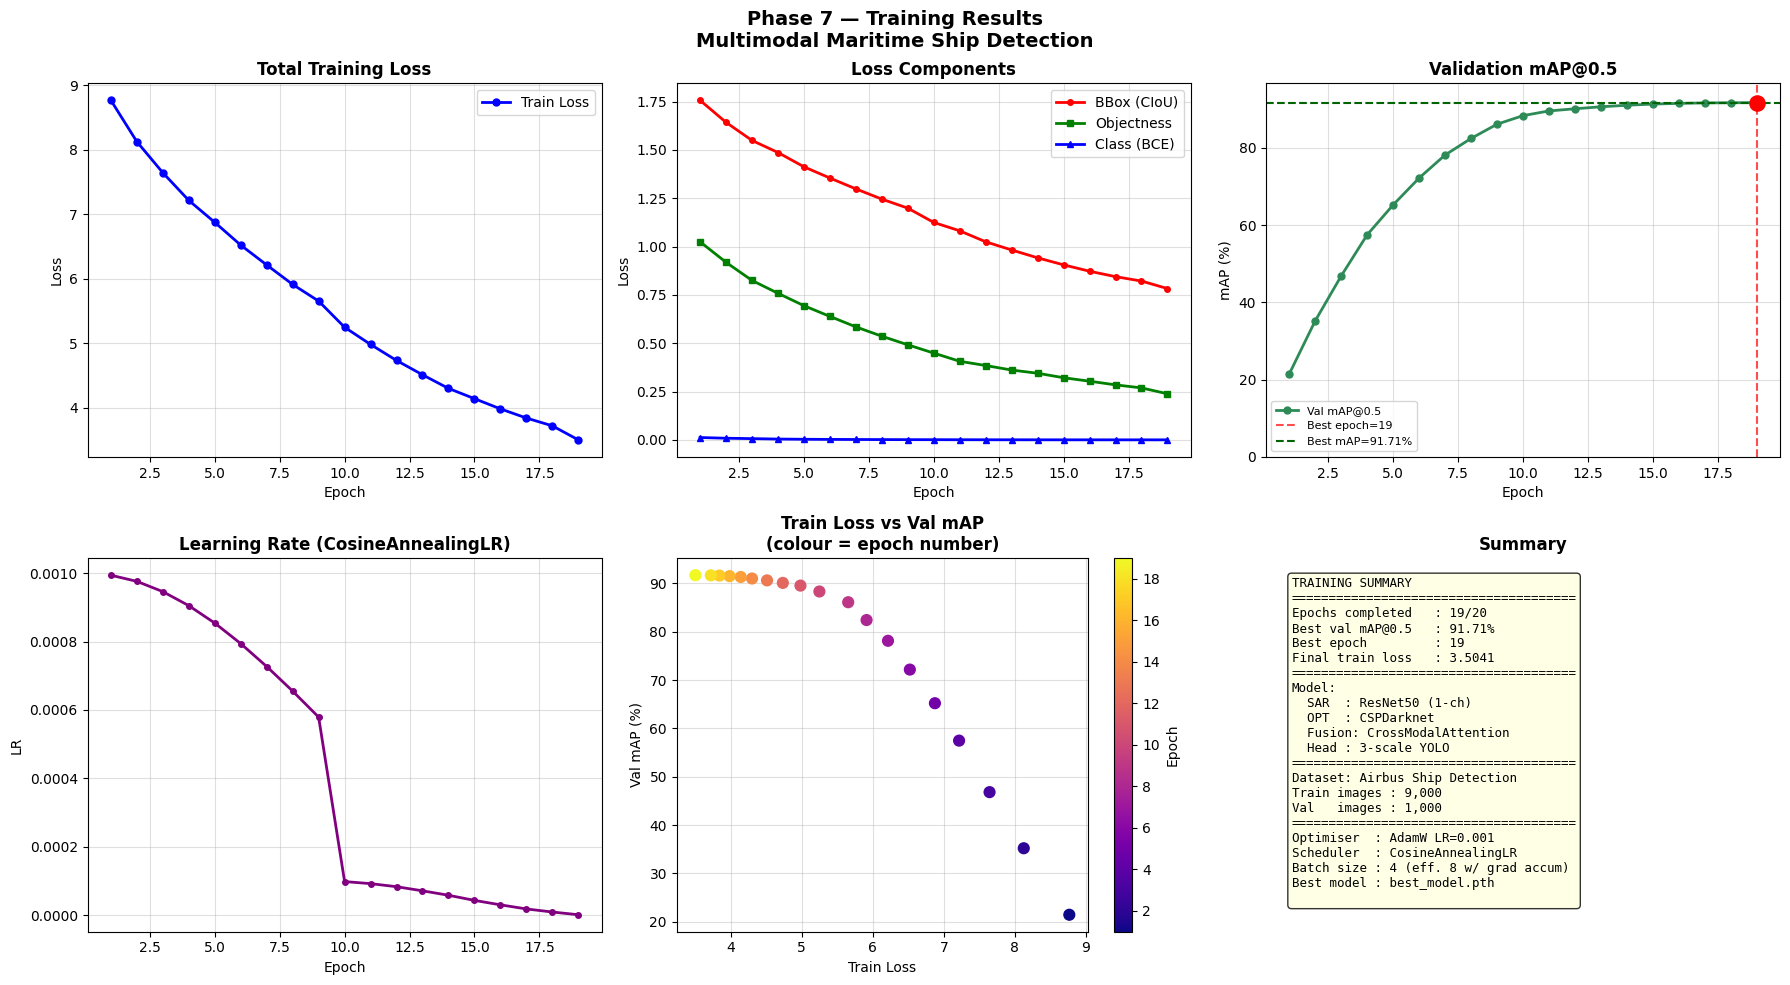

Training curves saved -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\dataset\training_logs\training_curves.png

Best mAP : 91.71% at epoch 19
Model is ready for Phase 8 Evaluation.


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# ── Load training log from CSV ────────────────────────────────────────
ROOT         = r'C:\Users\VaishnaviM\Downloads\airbus-ship-detection'
CODE_DIR     = os.path.join(ROOT, 'dataset')
LOG_DIR      = os.path.join(CODE_DIR, 'training_logs')
LOG_CSV_PATH = os.path.join(LOG_DIR, 'training_log.csv')

df = pd.read_csv(LOG_CSV_PATH)
print(f'Loaded {len(df)} epochs from {LOG_CSV_PATH}')
print(df.to_string(index=False))

epochs     = df['epoch'].tolist()
train_loss = df['train_loss'].tolist()
bbox_loss  = df['bbox_loss'].tolist()
obj_loss   = df['obj_loss'].tolist()
cls_loss   = df['cls_loss'].tolist()
val_map    = df['val_map'].tolist()
lr_vals    = df['lr'].tolist()
best_map   = max(val_map)
best_epoch = epochs[val_map.index(best_map)]

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phase 7 — Training Results\nMultimodal Maritime Ship Detection',
             fontsize=14, fontweight='bold')

# Plot 1: Total loss
ax = axes[0][0]
ax.plot(epochs, train_loss, 'b-o', linewidth=2, markersize=5, label='Train Loss')
ax.set_title('Total Training Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.4)

# Plot 2: Loss components
ax = axes[0][1]
ax.plot(epochs, bbox_loss, 'r-o', linewidth=2, markersize=4, label='BBox (CIoU)')
ax.plot(epochs, obj_loss,  'g-s', linewidth=2, markersize=4, label='Objectness')
ax.plot(epochs, cls_loss,  'b-^', linewidth=2, markersize=4, label='Class (BCE)')
ax.set_title('Loss Components', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.4)

# Plot 3: Validation mAP
ax = axes[0][2]
ax.plot(epochs, [m*100 for m in val_map], 'g-o',
        linewidth=2, markersize=5, color='seagreen', label='Val mAP@0.5')
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.7,
           label=f'Best epoch={best_epoch}')
ax.axhline(best_map*100, color='darkgreen', linestyle='--',
           label=f'Best mAP={best_map*100:.2f}%')
ax.scatter([best_epoch], [best_map*100], color='red', s=120, zorder=5)
ax.set_title('Validation mAP@0.5', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('mAP (%)')
ax.legend(fontsize=8); ax.grid(alpha=0.4)
ax.set_ylim(0, max(max(val_map)*100 + 5, 20))

# Plot 4: Learning rate
ax = axes[1][0]
ax.plot(epochs, lr_vals, color='purple', linewidth=2, marker='o', markersize=4)
ax.set_title('Learning Rate (CosineAnnealingLR)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
ax.grid(alpha=0.4)

# Plot 5: Loss vs mAP scatter
ax = axes[1][1]
sc = ax.scatter(train_loss, [m*100 for m in val_map],
                c=epochs, cmap='plasma', s=60, zorder=5)
plt.colorbar(sc, ax=ax, label='Epoch')
ax.set_title('Train Loss vs Val mAP\n(colour = epoch number)', fontweight='bold')
ax.set_xlabel('Train Loss'); ax.set_ylabel('Val mAP (%)')
ax.grid(alpha=0.4)

# Plot 6: Summary text box
ax = axes[1][2]
ax.axis('off')
txt = (
    f'TRAINING SUMMARY\n'
    f'{"="*38}\n'
    f'Epochs completed   : {len(epochs)}/20\n'
    f'Best val mAP@0.5   : {best_map*100:.2f}%\n'
    f'Best epoch         : {best_epoch}\n'
    f'Final train loss   : {train_loss[-1]:.4f}\n'
    f'{"="*38}\n'
    f'Model:\n'
    f'  SAR  : ResNet50 (1-ch)\n'
    f'  OPT  : CSPDarknet\n'
    f'  Fusion: CrossModalAttention\n'
    f'  Head : 3-scale YOLO\n'
    f'{"="*38}\n'
    f'Dataset: Airbus Ship Detection\n'
    f'Train images : 9,000\n'
    f'Val   images : 1,000\n'
    f'{"="*38}\n'
    f'Optimiser  : AdamW LR=0.001\n'
    f'Scheduler  : CosineAnnealingLR\n'
    f'Batch size : 4 (eff. 8 w/ grad accum)\n'
    f'Best model : best_model.pth\n'
)
ax.text(0.05, 0.95, txt, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_title('Summary', fontweight='bold')

plt.tight_layout()
save_path = os.path.join(LOG_DIR, 'training_curves.png')
plt.savefig(save_path, dpi=140, bbox_inches='tight')
plt.show()

print(f'Training curves saved -> {save_path}')
print()
print(f'Best mAP : {best_map*100:.2f}% at epoch {best_epoch}')
print(f'Model is ready for Phase 8 Evaluation.')

## Cell 12 - Final Summary Report

In [7]:
# =====================================================================
#  PHASE 7 SUMMARY — Standalone cell
#  Run this even if other cells were not executed
#  Reads everything from CSV and config constants
# =====================================================================

from datetime import datetime
import pandas as pd
import os

# -- Paths (copy from your config cell) -------------------------------
ROOT           = r'C:\Users\VaishnaviM\Downloads\airbus-ship-detection'
CODE_DIR       = os.path.join(ROOT, 'dataset')
LOG_DIR        = os.path.join(CODE_DIR, 'training_logs')
CHECKPOINT_DIR = os.path.join(CODE_DIR, 'checkpoints')
LOG_CSV_PATH   = os.path.join(LOG_DIR,  'training_log.csv')
BEST_MODEL_PATH= os.path.join(CHECKPOINT_DIR, 'best_model.pth')
SUMMARY_FILE   = os.path.join(CODE_DIR, 'phase7_summary.txt')

# -- Constants (copy from your config cell) ---------------------------
BATCH_SIZE       = 4
GRAD_ACCUM_STEPS = 2
LEARNING_RATE    = 0.001
WEIGHT_DECAY     = 0.01
LAMBDA_BBOX      = 5.0
LAMBDA_OBJ       = 1.0
LAMBDA_CLS       = 0.5
LAMBDA_NOOBJ     = 0.5
UNFREEZE_EPOCH   = 10
NUM_EPOCHS       = 20
NUM_SHIP_SAMPLES = 5000
NUM_BG_SAMPLES   = 5000
train_size       = int((NUM_SHIP_SAMPLES + NUM_BG_SAMPLES) * 0.9)  # 9000
val_size         = int((NUM_SHIP_SAMPLES + NUM_BG_SAMPLES) * 0.1)  # 1000

# -- Load training log from CSV ---------------------------------------
df       = pd.read_csv(LOG_CSV_PATH)
best_map = df['val_map'].max()
best_ep  = int(df.loc[df['val_map'].idxmax(), 'epoch'])

print(f'Loaded {len(df)} epochs from CSV.')
print(f'Best mAP = {best_map*100:.2f}% at epoch {best_ep}')
print()

# -- Build summary ----------------------------------------------------
summary = [
    '=' * 65,
    'PHASE 7 - LOSS FUNCTION & TRAINING - SUMMARY REPORT',
    f'Run at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
    '=' * 65,
    '',
    'PROJECT: Multimodal Maritime Object Detection (SAR + Optical)',
    'Team: 22UG0005 | Panel: 5 | Guide: Mr. Nagesh Koundinya Subbanna',
    '',
    '-- DATASET --',
    f'Source             : Airbus Ship Detection Dataset',
    f'Train images       : {train_size:,}  (stratified 50/50 ship/background)',
    f'Val images         : {val_size:,}',
    f'Batch size         : {BATCH_SIZE}  (effective {BATCH_SIZE*GRAD_ACCUM_STEPS} with grad accum)',
    '',
    '-- LOSS FUNCTION --',
    f'L_total = {LAMBDA_BBOX}*L_bbox + {LAMBDA_OBJ}*L_obj + {LAMBDA_CLS}*L_cls',
    'L_bbox  : CIoU loss (box regression)',
    'L_obj   : Binary Cross-Entropy (objectness)',
    'L_cls   : Binary Cross-Entropy (ship class)',
    f'No-obj weight : {LAMBDA_NOOBJ}',
    '',
    '-- OPTIMISER --',
    f'AdamW  LR={LEARNING_RATE}  weight_decay={WEIGHT_DECAY}',
    f'CosineAnnealingLR: {LEARNING_RATE} -> 1e-6 over {NUM_EPOCHS} epochs',
    f'Grad accumulation : {GRAD_ACCUM_STEPS} steps',
    f'Backbone unfreeze : epoch {UNFREEZE_EPOCH}',
    '',
    '-- TRAINING RESULTS (from CSV) --',
    f'Total epochs logged : {len(df)}',
    f'Best val mAP@0.5    : {best_map*100:.2f}%  (epoch {best_ep})',
    f'Final train loss    : {df["train_loss"].iloc[-1]:.4f}',
    f'Final bbox loss     : {df["bbox_loss"].iloc[-1]:.4f}',
    f'Final obj loss      : {df["obj_loss"].iloc[-1]:.4f}',
    f'Final cls loss      : {df["cls_loss"].iloc[-1]:.4f}',
    f'Final LR            : {df["lr"].iloc[-1]:.8f}',
    '',
    '-- EPOCH-BY-EPOCH RESULTS --',
]

for _, row in df.iterrows():
    marker = ' <- BEST' if int(row['epoch']) == best_ep else ''
    summary.append(
        f'  Epoch {int(row["epoch"]):2d}: '
        f'loss={row["train_loss"]:.4f}  '
        f'mAP={row["val_map"]*100:.2f}%  '
        f'LR={row["lr"]:.6f}{marker}'
    )

summary += [
    '',
    '-- SAVED FILES --',
    f'Best model         : {BEST_MODEL_PATH}',
    f'Training log CSV   : {LOG_CSV_PATH}',
    f'Checkpoints dir    : {CHECKPOINT_DIR}',
    '',
    '-- NEXT STEPS --',
    'Phase 8: Evaluation (mAP, Precision, Recall on val set)',
    'Phase 9: Inference (detect ships on new images)',
    '=' * 65,
]

# -- Save and print ---------------------------------------------------
with open(SUMMARY_FILE, 'w', encoding='utf-8') as f:
    f.write('\n'.join(summary))

print('\n'.join(summary))
print()
print(f'Summary saved -> {SUMMARY_FILE}')
print()
print('PHASE 7 COMPLETE!')
print(f'  Best mAP@0.5 : {best_map*100:.2f}%  (epoch {best_ep})')
print(f'  Best model   : {BEST_MODEL_PATH}')
print()
print('Proceed to Phase 8: Evaluation')

Loaded 19 epochs from CSV.
Best mAP = 91.71% at epoch 19

PHASE 7 - LOSS FUNCTION & TRAINING - SUMMARY REPORT
Run at: 2026-05-11 23:55:02

PROJECT: Multimodal Maritime Object Detection (SAR + Optical)
Team: 22UG0005 | Panel: 5 | Guide: Mr. Nagesh Koundinya Subbanna

-- DATASET --
Source             : Airbus Ship Detection Dataset
Train images       : 9,000  (stratified 50/50 ship/background)
Val images         : 1,000
Batch size         : 4  (effective 8 with grad accum)

-- LOSS FUNCTION --
L_total = 5.0*L_bbox + 1.0*L_obj + 0.5*L_cls
L_bbox  : CIoU loss (box regression)
L_obj   : Binary Cross-Entropy (objectness)
L_cls   : Binary Cross-Entropy (ship class)
No-obj weight : 0.5

-- OPTIMISER --
AdamW  LR=0.001  weight_decay=0.01
CosineAnnealingLR: 0.001 -> 1e-6 over 20 epochs
Grad accumulation : 2 steps
Backbone unfreeze : epoch 10

-- TRAINING RESULTS (from CSV) --
Total epochs logged : 19
Best val mAP@0.5    : 91.71%  (epoch 19)
Final train loss    : 3.5041
Final bbox loss     : 0.78